notebooks/01_eda.py
===================
Exploratory Data Analysis — saved as a .py script so it can also be run
standalone without Jupyter.  Open as a notebook by converting with:
    jupyter nbconvert --to notebook --execute notebooks/01_eda.py

PURPOSE
-------
Before building any model or segment, we need to understand the shape of the
data:
  - What does revenue look like over time? (trend, seasonality)
  - Which products and countries dominate?
  - How are order values and frequencies distributed?

These questions aren't just exploratory — each finding either validates or
challenges assumptions in the business problem statement, and each chart
should be able to answer "so what?" for a non-technical stakeholder.

HOW TO READ THIS NOTEBOOK
--------------------------
Every code block is paired with a markdown interpretation of the finding.
When you see "BUSINESS IMPLICATION:", that text is what you'd say to the VP
in a presentation — it directly connects the data observation to a decision.

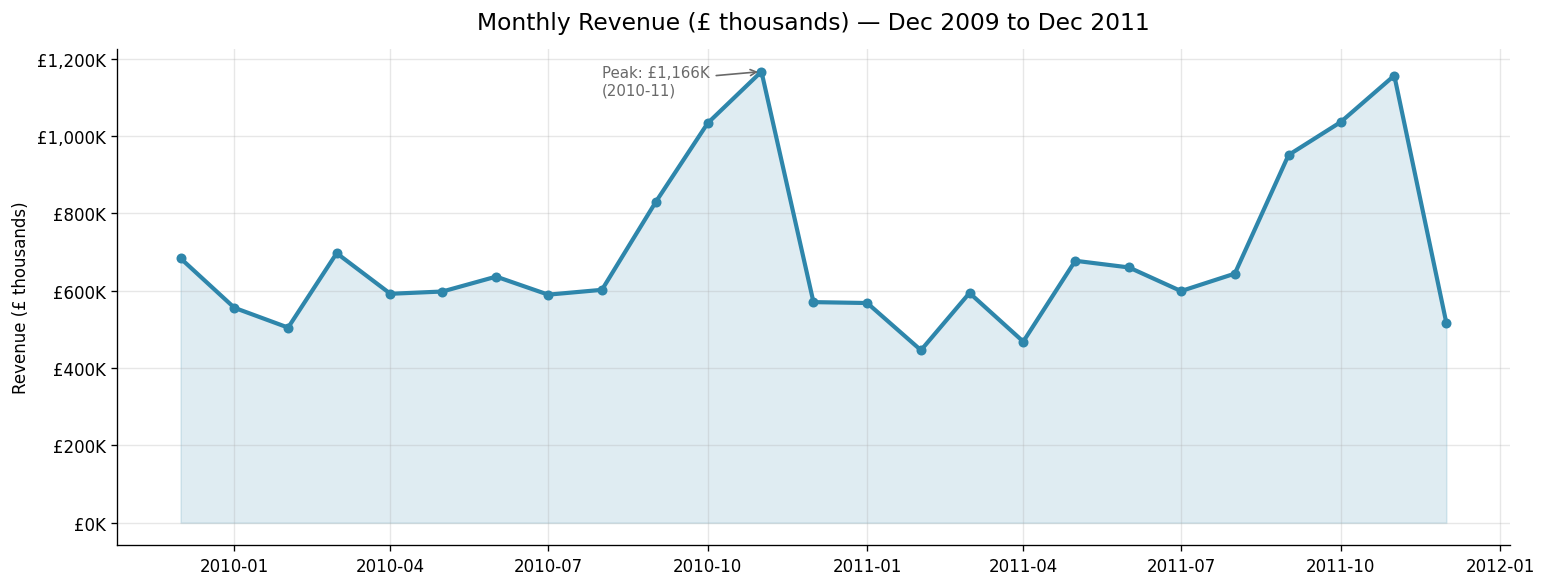

In [ ]:
# ── 0. Imports and setup ─────────────────────────────────────────────────────
import sys
import os
from pathlib import Path

# Resolve project root (one level up from notebooks/) and add to path,
# regardless of which directory the script is invoked from.
_NOTEBOOK_DIR = Path(__file__).resolve().parent
_PROJECT_ROOT = _NOTEBOOK_DIR.parent
sys.path.insert(0, str(_PROJECT_ROOT))
os.chdir(_PROJECT_ROOT)   # make all relative paths work from project root

import matplotlib
matplotlib.use('Agg')      # non-interactive backend: saves figures to disk without
                           # opening any GUI windows — required for headless execution

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Style: clean, consistent plot aesthetics throughout
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.family": "sans-serif",
})
PALETTE = "#2E86AB"   # consistent brand colour throughout
OUTPUT_DIR = _PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = _PROJECT_ROOT / "data" / "processed" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── 1. Load cleaned data ──────────────────────────────────────────────────────
# WHY parquet: reading from a pre-cleaned parquet is ~10x faster than re-parsing
# the CSV.  The cleaning decisions are documented in src/data_cleaning.py.
df = pd.read_parquet(_PROJECT_ROOT / "data" / "processed" / "cleaned.parquet", engine="pyarrow")

# Add convenient time columns
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()

print(f"Loaded {len(df):,} rows | {df['CustomerID'].nunique():,} customers | "
      f"{df['Invoice'].nunique():,} invoices")
print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")


# ============================================================================
# SECTION 1: REVENUE TRENDS OVER TIME
# ============================================================================
# BUSINESS QUESTION: Is the business growing, flat, or declining?
# Is there a seasonal pattern we should plan operations around?

print("\n--- Section 1: Revenue Trends ---")

monthly_rev = (
    df.groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)
monthly_rev["YearMonth_dt"] = monthly_rev["YearMonth"].dt.to_timestamp()
monthly_rev["Revenue_K"] = monthly_rev["Revenue"] / 1000  # convert to £ thousands

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(
    monthly_rev["YearMonth_dt"],
    monthly_rev["Revenue_K"],
    alpha=0.15,
    color=PALETTE,
)
ax.plot(
    monthly_rev["YearMonth_dt"],
    monthly_rev["Revenue_K"],
    color=PALETTE,
    linewidth=2.5,
    marker="o",
    markersize=5,
)
ax.set_title("Monthly Revenue (£ thousands) — Dec 2009 to Dec 2011", fontsize=14, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Revenue (£ thousands)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}K"))

# Annotate the November 2011 peak (Christmas build-up)
peak_row = monthly_rev.loc[monthly_rev["Revenue_K"].idxmax()]
ax.annotate(
    f"Peak: £{peak_row['Revenue_K']:,.0f}K\n({peak_row['YearMonth']})",
    xy=(peak_row["YearMonth_dt"], peak_row["Revenue_K"]),
    xytext=(peak_row["YearMonth_dt"] - pd.DateOffset(months=3), peak_row["Revenue_K"] * 0.95),
    arrowprops=dict(arrowstyle="->", color="dimgray"),
    fontsize=9,
    color="dimgray",
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_monthly_revenue.png", bbox_inches="tight")
plt.show()
print("Saved: 01_monthly_revenue.png")

FINDING: Revenue shows a clear upward trend from 2010 into 2011, with a
pronounced spike in November of both years — consistent with Christmas
gifting demand.  The dip in December 2011 is likely due to data cut-off
(the dataset ends 9 Dec 2011, so we only see 9 days of that month).

BUSINESS IMPLICATION: Operations, inventory, and marketing should plan
for a ~2x revenue surge in October-November relative to the annual average.
The Q4 ramp-up is the single most important planning period for this business.

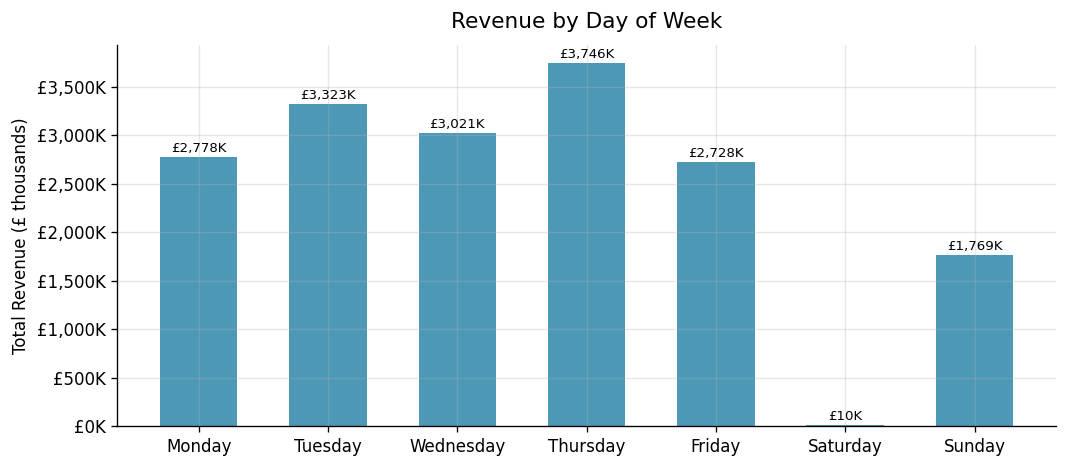

In [ ]:
# ── 1b. Day-of-week revenue pattern ──────────────────────────────────────────
# BUSINESS QUESTION: Are there intra-week patterns relevant to ad scheduling
# or logistics staffing?

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_rev = (
    df.groupby("DayOfWeek")["Revenue"]
    .sum()
    .reindex(day_order)
    .reset_index()
)
dow_rev["Revenue_K"] = dow_rev["Revenue"] / 1000

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(dow_rev["DayOfWeek"], dow_rev["Revenue_K"], color=PALETTE, alpha=0.85, width=0.6)
ax.set_title("Revenue by Day of Week", fontsize=13, pad=10)
ax.set_ylabel("Total Revenue (£ thousands)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}K"))
# Label each bar
for bar, val in zip(bars, dow_rev["Revenue_K"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"£{val:,.0f}K", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01b_day_of_week_revenue.png", bbox_inches="tight")
plt.show()
print("Saved: 01b_day_of_week_revenue.png")

FINDING: The vast majority of revenue is generated Monday–Thursday.  Sunday
is near zero, and Saturday is very low.  This is a B2B-influenced pattern —
the customer base includes many small retailers and gift shop owners who
place orders during business hours.

BUSINESS IMPLICATION: Marketing emails and promotions should be scheduled
Tuesday-Thursday for maximum open rates. Customer service staffing can be
lean on weekends.

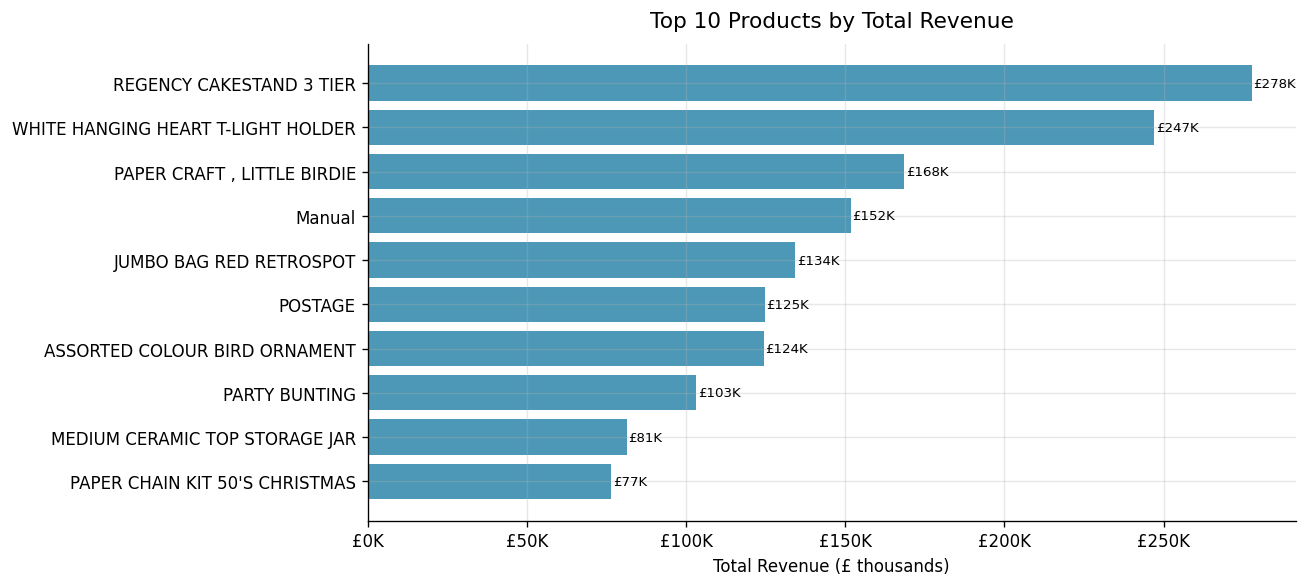

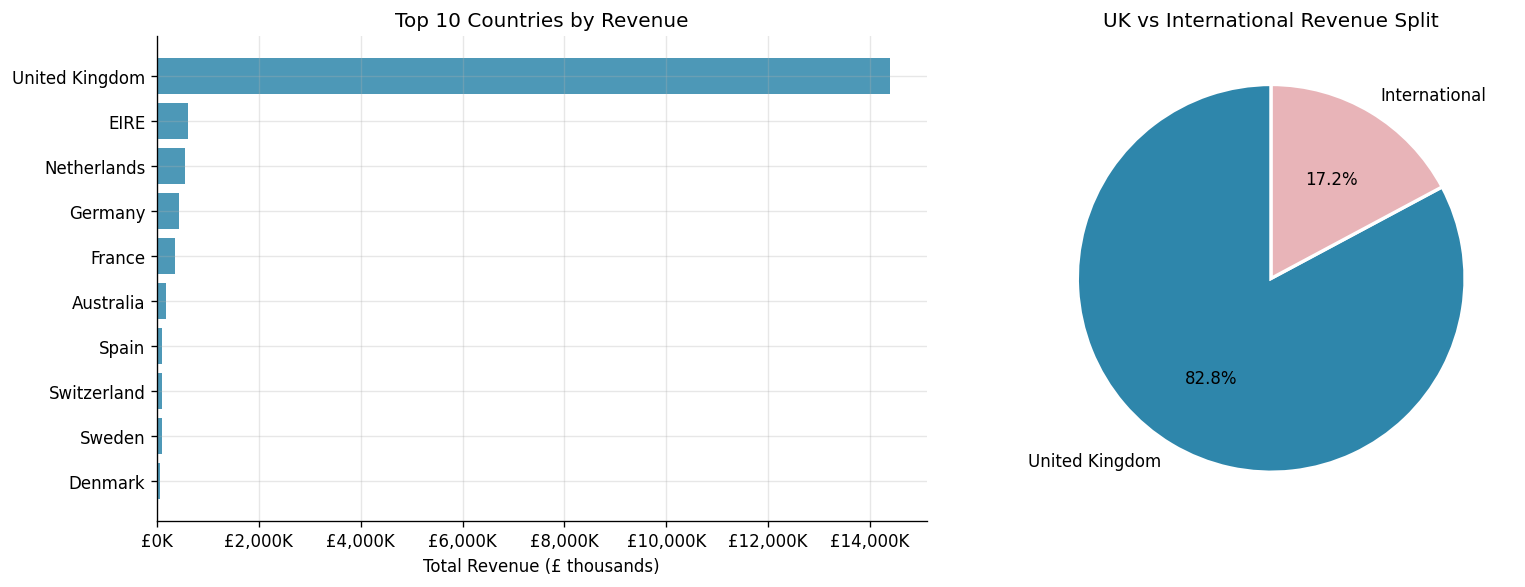

In [ ]:
# ============================================================================
# SECTION 2: TOP PRODUCTS AND COUNTRIES
# ============================================================================
print("\n--- Section 2: Top Products and Countries ---")

# ── 2a. Top 10 products by revenue ──────────────────────────────────────────
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .nlargest(10)
    .reset_index()
)
top_products["Revenue_K"] = top_products["Revenue"] / 1000

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(
    top_products["Description"][::-1],
    top_products["Revenue_K"][::-1],
    color=PALETTE,
    alpha=0.85,
)
ax.set_title("Top 10 Products by Total Revenue", fontsize=13, pad=10)
ax.set_xlabel("Total Revenue (£ thousands)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}K"))
for bar, val in zip(bars, top_products["Revenue_K"][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"£{val:,.0f}K", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02a_top_products_revenue.png", bbox_inches="tight")
plt.show()
print("Saved: 02a_top_products_revenue.png")


# ── 2b. Top 10 countries by revenue ─────────────────────────────────────────
top_countries = (
    df.groupby("Country")["Revenue"]
    .sum()
    .nlargest(10)
    .reset_index()
)
top_countries["Revenue_K"] = top_countries["Revenue"] / 1000
top_countries["Pct"] = top_countries["Revenue"] / df["Revenue"].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart
axes[0].barh(
    top_countries["Country"][::-1],
    top_countries["Revenue_K"][::-1],
    color=PALETTE,
    alpha=0.85,
)
axes[0].set_title("Top 10 Countries by Revenue", fontsize=12)
axes[0].set_xlabel("Total Revenue (£ thousands)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}K"))

# Right: pie chart (UK vs rest of world)
uk_rev = df[df["Country"] == "United Kingdom"]["Revenue"].sum()
intl_rev = df[df["Country"] != "United Kingdom"]["Revenue"].sum()
axes[1].pie(
    [uk_rev, intl_rev],
    labels=["United Kingdom", "International"],
    autopct="%1.1f%%",
    colors=[PALETTE, "#E8B4B8"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("UK vs International Revenue Split", fontsize=12)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02b_top_countries.png", bbox_inches="tight")
plt.show()
print("Saved: 02b_top_countries.png")

# Print the table for reference
print("\nTop 10 countries by revenue:")
print(top_countries[["Country", "Revenue_K", "Pct"]].to_string(index=False))

FINDING: The United Kingdom dominates, accounting for roughly 80%+ of total
revenue.  The next largest markets are Germany, France, Ireland, and the
Netherlands.

BUSINESS IMPLICATION: While the business is technically international, it is
operationally a UK business with export sales.  Internationalisation is an
opportunity but our customer analytics should be UK-primary.  When the
Retention team designs campaigns, they should localise messaging for UK first,
with German/French as the only secondary markets worth investment.

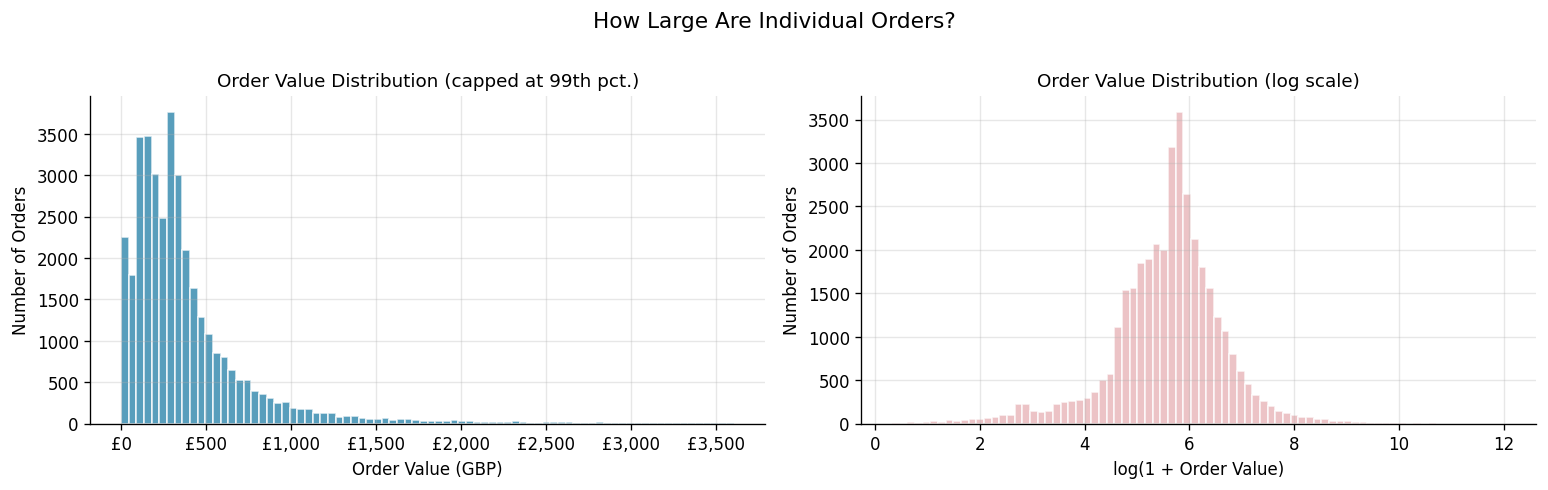

In [ ]:
# ============================================================================
# SECTION 3: ORDER VALUE AND FREQUENCY DISTRIBUTIONS
# ============================================================================
print("\n--- Section 3: Order value and frequency distributions ---")

# Build order-level summary
order_summary = (
    df.groupby("Invoice")
    .agg(
        OrderValue=("Revenue", "sum"),
        NumItems=("Quantity", "sum"),
        CustomerID=("CustomerID", "first"),
    )
    .reset_index()
)

# ── 3a. Order value distribution ─────────────────────────────────────────────
# WHY log scale: order values span several orders of magnitude. A linear
# histogram would show one enormous bar at the low end and nothing else.
# Log scale reveals the full distribution shape.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Cap at 99th percentile to avoid extreme outliers distorting the chart
p99 = order_summary["OrderValue"].quantile(0.99)
order_vals_capped = order_summary.loc[order_summary["OrderValue"] <= p99, "OrderValue"]

axes[0].hist(order_vals_capped, bins=80, color=PALETTE, alpha=0.8, edgecolor="white")
axes[0].set_title("Order Value Distribution (capped at 99th pct.)", fontsize=11)
axes[0].set_xlabel("Order Value (GBP)")
axes[0].set_ylabel("Number of Orders")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))

# Log scale version
axes[1].hist(np.log1p(order_summary["OrderValue"]), bins=80, color="#E8B4B8", alpha=0.8, edgecolor="white")
axes[1].set_title("Order Value Distribution (log scale)", fontsize=11)
axes[1].set_xlabel("log(1 + Order Value)")
axes[1].set_ylabel("Number of Orders")

plt.suptitle("How Large Are Individual Orders?", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03a_order_value_dist.png", bbox_inches="tight")
plt.show()
print("Saved: 03a_order_value_dist.png")

# Summary stats
print("\nOrder value summary statistics:")
print(order_summary["OrderValue"].describe().apply(lambda x: f"£{x:,.2f}"))

FINDING: The order value distribution is heavily right-skewed. The median
order is modest (a few hundred pounds), but there is a long tail of very
large orders (thousands of pounds). This is consistent with a business serving
both retail consumers and wholesale/trade buyers.

BUSINESS IMPLICATION: The top decile of orders by value likely comes from a
small number of trade customers. Losing even one of these customers would have
a disproportionate revenue impact. This reinforces the case for a high-value
customer retention programme.

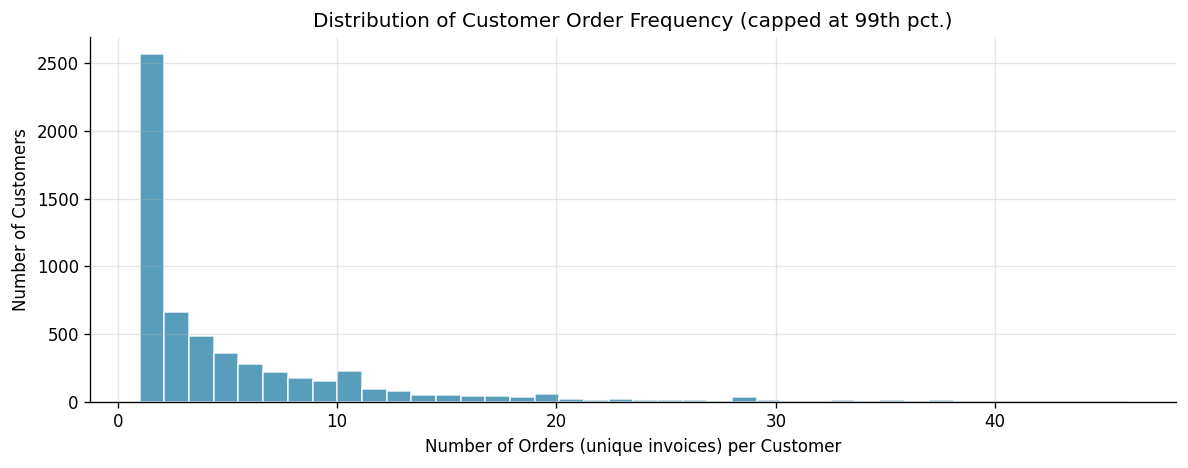

In [ ]:
# ── 3b. Order frequency distribution ─────────────────────────────────────────
# How often do individual customers place orders?
customer_freq = (
    df.groupby("CustomerID")["Invoice"]
    .nunique()
    .reset_index()
    .rename(columns={"Invoice": "OrderCount"})
)

fig, ax = plt.subplots(figsize=(10, 4))
# Cap at 99th percentile
p99_freq = customer_freq["OrderCount"].quantile(0.99)
freq_capped = customer_freq.loc[customer_freq["OrderCount"] <= p99_freq, "OrderCount"]
ax.hist(freq_capped, bins=40, color=PALETTE, alpha=0.8, edgecolor="white")
ax.set_title("Distribution of Customer Order Frequency (capped at 99th pct.)", fontsize=12)
ax.set_xlabel("Number of Orders (unique invoices) per Customer")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03b_order_frequency_dist.png", bbox_inches="tight")
plt.show()
print("Saved: 03b_order_frequency_dist.png")

print("\nCustomer order frequency summary:")
print(customer_freq["OrderCount"].describe().apply(lambda x: f"{x:,.1f}"))

# Pareto check: what share of customers drive what share of revenue?
customer_rev = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
total_rev = customer_rev.sum()
top_20pct_cutoff = int(len(customer_rev) * 0.20)
top_20pct_rev = customer_rev.iloc[:top_20pct_cutoff].sum()
print(f"\nPareto check:")
print(f"  Top 20% of customers ({top_20pct_cutoff:,} customers) "
      f"generate {top_20pct_rev/total_rev:.1%} of total revenue")

FINDING: Most customers place only 1-3 orders in the two-year period, but a
meaningful tail of repeat buyers exists. The Pareto analysis will confirm
whether the classic 80/20 rule applies — if top 20% of customers generate
~80% of revenue, the case for targeted retention is very strong.

BUSINESS IMPLICATION: High order-frequency customers are likely trade buyers
(small retailers restocking regularly). These are the most valuable relationships
and should be handled with a dedicated account management approach, not generic
CRM campaigns.

In [ ]:
print("\nEDA complete. All figures saved to data/processed/figures/")